# Project 5 -- Boqiang Zhang

**TA Help:** None

**Collaboration:** None

**Internet Resources:** None

**ChatGPT, Gemini, Claude, etc:** Gemini, link: TBD

- In Q1, I asked Gemini about the step 'logits = self(x)' and what logits mean
- In Q2, I asked Gemini about what .dropna does in pandas
- In Q2, I asked Gemini about logging in pl.Trainer
- In Q3, I asked Gemini about the decorator @classmethod
- In Q3, I asked Gemini to help debug a python confliction issue and discussed quite a lot about it
- In Q5, I asked Gemini to briefly explain dataframe to me.

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

### 1.1 Two-three sentences explaining the general flow and benefits of this setup.

- We use instead a class to define the training and verification process. This makes it more modular and easier to maintain. It can also benefit from pre-defined classes (e.g. LightningModule) to use optimized functions and attributes.

### 1.2 Run `!cat {your_path_to_project}/intro_mlops_2/src/lightning.py`.

In [1]:
path = '~/seminar-project/project5'

In [5]:
!cat {path}/intro_mlops_2/src/lightning.py

# src/lightning.py

import pytorch_lightning as pl
import torch
from torch import nn

class WineQualityClassifier(pl.LightningModule):
    def __init__(self, model, learning_rate, epochs):
        super().__init__()
        self.save_hyperparameters(ignore=["model"]) # don't serialize the model object
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss() # cross entropy loss is a common loss function for classification tasks

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch                      # splits out data (`x`) and labels (`y`)
        logits = self(x)                  # passes data into models forward method
        loss = self.loss_fn(logits, y)    # calcs loss based on logits (output of model) and ground truth
        self.log("train_loss", loss)      # this is a special method that logs the loss at each step
        return loss

    def configure_optimizers(self):
        # uses self

## Question 2

### Before deliverables

In [2]:
import pandas as pd

data = pd.read_csv('/anvil/projects/tdm/data/wine/wine_quality_type.csv')
print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8        5  red  
2    

### 2.1 Run `!cat {path}/intro_mlops_2/src/data_loader.py | head -n 45`.

In [6]:
!cat {path}/intro_mlops_2/src/data_loader.py | head -n 45

# src/data_loader.py - project 5 version

import pytorch_lightning as pl
import pandas as pd
import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

class WineQualityDataModule(pl.LightningDataModule):
    def __init__(self, data_path, batch_size=32, train_split=0.8): # you can add more parameters here if you want
        super().__init__()
        self.data_path = data_path
        self.batch_size = batch_size
        self.train_split = train_split

    def setup(self, stage=None):
        # Load and preprocess data - same logic from load_and_preprocess_data()
        data = pd.read_csv(self.data_path).dropna()

        # Create quality bins
        def bin_quality(quality):
            if quality <= 4:
                return 0  # Bad
            elif quality <= 7:
                return 1  # Mid
            else:
                return 2  # Good

  

### 2.2 Run `!cat {path}/intro_mlops_2/main.py`.

In [10]:
!cat {path}/intro_mlops_2/main.py

import pytorch_lightning as pl

from intro_mlops_2.src.lightning import WineQualityClassifier
from intro_mlops_2.src.data_loader import WineQualityDataModule
from intro_mlops_2.src.config import DATA_PATH, MODEL_PATH, PLOT_PATH, LOGS_PATH, \
    TRAIN_SPLIT, BATCH_SIZE, LEARNING_RATE, EPOCHS, INPUT_SIZE, NUM_CLASSES
from intro_mlops_2.src.neural_net import SimpleNN


def main():
    # Initialize model and dataloader
    simple_nn = SimpleNN(INPUT_SIZE, NUM_CLASSES)
    model = WineQualityClassifier(simple_nn, learning_rate=LEARNING_RATE, epochs=EPOCHS)
    datamodule = WineQualityDataModule(data_path=DATA_PATH / "wine_quality_type.csv", batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT)

    # Initialize trainer object and train
    trainer = pl.Trainer(max_epochs=model.hparams.epochs)
    trainer.fit(model, datamodule=datamodule)

if __name__ == "__main__":
    main()


### 2.3 Run the pipline (in the notebook under the `intro_mlops_2/notebooks/` directory): `!cd ../../; python -m intro_mlops_2.main`.

In [11]:
!cd ../../; python -m intro_mlops_2.main

/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
2026-02-25 18:26:17.341760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772061977.356749 1201690 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772061977.361620 1201690 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1

## Question 3

### 3.1 Run `print_directory_tree` to show the new changes.

In [2]:
import os

def print_directory_tree(root_dir, max_depth=3):
  root_dir = os.path.abspath(os.path.expanduser(root_dir))

  if not os.path.exists(root_dir):
    print(f"Path does not exist: {root_dir}")
    return

  for root, dirs, files in os.walk(root_dir):
    # Skip hidden directories like .git
    dirs[:] = [d for d in dirs if not d.startswith(".") and d != ("__pycache__")]
    files = [f for f in files if not f.startswith(".")]

    level = root.replace(root_dir, "").count(os.sep)
    if level >= max_depth:
      continue

    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for f in files:
      print(f"{subindent}{f}")

project_dir = "~/seminar-project/project5"
root_path = f"{project_dir}/intro_mlops_2/" # adjust as needed

In [4]:
print_directory_tree(root_path)

intro_mlops_2/
    requirements.txt
    main.py
    README.md
    app.py
    __init__.py
    models/
        label_encoder.pkl
        best_model.pth
    logs/
        training.log
        debug.log
        results.log
        error.log
    configs/
        validation.py
        __init__.py
        config.py
        model.yaml
        experiments.yaml
    data/
        data.csv
    notebooks/
        boqiang_zhang_project5.ipynb
        analysis.ipynb
    plots/
        accuracy_plot.png
        training_loss_plot.png
    src/
        data_loader.py
        lightning.py
        __init__.py
        neural_net.py
        visualization.py
        trainer.py
        metrics.py


### 3.2 Load the configs successfully in your notebook.

In [6]:
# notebooks/your_notebook.ipynb
import sys
from pathlib import Path

sys.path.append(str(Path("../..").resolve()))

from intro_mlops_2.configs.validation import load_config
from pathlib import Path

path = Path(f"{project_dir}/intro_mlops_2/configs/model.yaml").expanduser()
config = load_config(path)
print(config)
print("training: ", config.training)
print("model: ", config.model)

training=TrainingConfig(train_split=0.8, batch_size=32, learning_rate=0.001, epochs=5) model=ModelConfig(input_size=11, num_classes=3)
training:  train_split=0.8 batch_size=32 learning_rate=0.001 epochs=5
model:  input_size=11 num_classes=3


### 3.3 Change a value in the model.yaml that would break and see the output.

- I changed input_size of model from 11 to 11.1

In [7]:
config = load_config(path)
print(config)
print("training: ", config.training)
print("model: ", config.model)

ValidationError: 1 validation error for FullConfig
model.input_size
  Input should be a valid integer, got a number with a fractional part [type=int_from_float, input_value=11.1, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/int_from_float

## Question 4

### 4.1 Run the pipeline (with no callbacks or logging) and check the output.

In [8]:
# notebooks/your_notebook.ipynb
!cd ../../; python -m intro_mlops_2.main

/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
2026-02-25 23:05:11.426407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772078711.608202  673659 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772078711.652637  673659 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1

### 4.2 Show contents of the `lightning_logs/` directory.

In [10]:
# notebooks/your_notebook.ipynb
root_path = "~/seminar-project/project5/lightning_logs" # adjust as needed
print_directory_tree(root_path, max_depth=3)

lightning_logs/
    version_15413175/
        hparams.yaml
        events.out.tfevents.1772061984.a186.anvil.rcac.purdue.edu.1201690.0
        events.out.tfevents.1772061631.a186.anvil.rcac.purdue.edu.1198878.0
        checkpoints/
            epoch=4-step=815.ckpt
            epoch=4-step=815-v1.ckpt
    version_15415912/
        events.out.tfevents.1772078736.a248.anvil.rcac.purdue.edu.673659.1
        events.out.tfevents.1772078721.a248.anvil.rcac.purdue.edu.673659.0
        hparams.yaml
        checkpoints/
            epoch=4-step=815.ckpt


### 4.3 Run the pipeline with callbacks and logging enabled and check the output.

In [12]:
# notebooks/your_notebook.ipynb
!cd ../../; python -m intro_mlops_2.main

/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
|                             Training started...                              |
/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/x-bzhang23/seminar-project/project5/intro_mlops_2/models exists and is not empty.

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | SimpleNN         | 2.9 K  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
2.9 K     Trainable params
0         Non-trainable params
2.9 K     Total params
0.012     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handle

### 4.4 Show contents of the `intro_mlops_2/logs/` directory.

In [ ]:
# notebooks/your_notebook.ipynb
root_path = "~/seminar-project/project5/intro_mlops_2/logs/" # adjust as needed
print_directory_tree(root_path, max_depth=3)

root_path = "~/seminar-project/project5/intro_mlops_2/models/" # adjust as needed
print_directory_tree(root_path, max_depth=3)

logs/
    training.log
    debug.log
    results.log
    error.log
    wine_quality/
        version_0/
            metrics.csv
            hparams.yaml
models/
    best-epoch=04-val_loss=0.26.ckpt
    label_encoder.pkl
    best_model.pth


## Question 5

### 5.1 Training wrapped in an MLflow run with params and final validation metrics logged.

In [3]:
# notebooks/your_notebook.ipynb
!cd ../../; python -m intro_mlops_2.main

/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
2026-03-03 21:55:44.159114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772592944.343899 1200684 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772592944.389884 1200684 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772592944.856684 1200684 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772592944.856718 1200684 compu

### 5.2 Model saved via mlflow.pytorch.log_model.


In [4]:
# notebooks/your_notebook.ipynb
root_path = "~/seminar-project/project5/mlruns" # adjust as needed
print_directory_tree(root_path, max_depth=3)

root_path = "~/seminar-project/project5/intro_mlops_2/models/" # adjust as needed
print_directory_tree(root_path, max_depth=3)

mlruns/
    770249009377217944/
        meta.yaml
        96d79a82d5cc4725ba74cf9c8cc75b34/
            meta.yaml
        models/
        6165f6d8b7a04d4f995a93cb0855b133/
            meta.yaml
    0/
        meta.yaml
models/
    best-epoch=04-val_loss=0.26.ckpt
    best-epoch=04-val_loss=0.26-v2.ckpt
    label_encoder.pkl
    best_model.pth
    best-epoch=04-val_loss=0.26-v1.ckpt


### 5.3 See the runs and the best run.

                             run_id     start_time epochs  learning_rate  \
0  6165f6d8b7a04d4f995a93cb0855b133  1772592942235      5          0.001   
1  96d79a82d5cc4725ba74cf9c8cc75b34  1772083245437      5          0.001   

   val_loss  val_accuracy  
0  0.262106      0.933846  
1  0.262106      0.933846  


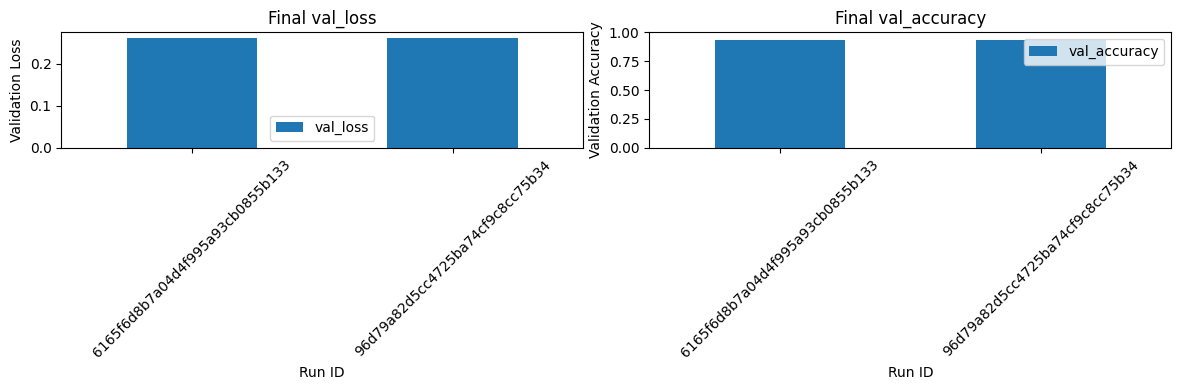

Best run: 6165f6d8b7a04d4f995a93cb0855b133 with val_loss=0.2621 and val_accuracy=0.9338


,run_id,start_time,epochs,learning_rate,val_loss,val_accuracy
0,6165f6d8b7a04d4f995a93cb0855b133,1772592942235,5,0.001,0.262106,0.933846
1,96d79a82d5cc4725ba74cf9c8cc75b34,1772083245437,5,0.001,0.262106,0.933846


In [5]:
# notebooks/your_notebook.ipynb
import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()  # adjust if needed
# print(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from intro_mlops_2.src.see_runs import see_runs

see_runs()

## Question 6

### 6.1 Request/response validation with Pydantic (`WineQualityRequest` and `WineQualityResponse`).

In [7]:
# notebooks/your_notebook.ipynb
root_path = "~/seminar-project/project5/intro_mlops_2" # adjust as needed
!cat {root_path}/configs/api_validation.py

# configs/api_validation.py
from pydantic import BaseModel

class WineQualityRequest(BaseModel):
    fixed_acidity: float
    volatile_acidity: float
    citric_acid: float
    residual_sugar: float
    chlorides: float
    free_sulfur_dioxide: float
    total_sulfur_dioxide: float
    density: float
    pH: float
    sulphates: float
    alcohol: float
    # add the rest of the feature fields to match your model's input (same order as training data)

class WineQualityResponse(BaseModel):
    quality: str

### 6.2 Model loaded from `MLflow` (e.g. via `get_latest_model`) and used in `FastAPI`.

In [8]:
# notebooks/your_notebook.ipynb
root_path = "~/seminar-project/project5/intro_mlops_2" # adjust as needed
!cat {root_path}/app.py

# app.py
import torch
import pickle
import mlflow

from intro_mlops_2.configs.config import MODEL_PATH
from mlflow.tracking import MlflowClient
from fastapi import FastAPI
from intro_mlops_2.configs.api_validation import WineQualityRequest, WineQualityResponse

def get_latest_model():
    client = MlflowClient()
    experiment = client.get_experiment_by_name("WineQualityClassifier")
    latest_run = client.search_runs(experiment_ids=[experiment.experiment_id], order_by=["start_time DESC"], max_results=1)[0]
    model_uri = f"runs:/{latest_run.info.run_id}/model"
    return mlflow.pytorch.load_model(model_uri)

app = FastAPI()
model = get_latest_model()
model.eval()

with open(MODEL_PATH / "label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

@app.post("/predict", response_model=WineQualityResponse)
async def predict(input_data: WineQualityRequest):
    features = torch.FloatTensor([
        input_data.fixed_acidity,
        input_data.volatile_acidity,
        input_data

### 6.3 Output from an invalid formatted request (should error).

In [9]:
import requests

url = "http://0.0.0.0:8000/predict"
data = [5.1, 3.5, 1.4, 0.2]

response = requests.post(url, json=data)
prediction = response.json()

print(prediction)

{'detail': [{'type': 'model_attributes_type', 'loc': ['body'], 'msg': 'Input should be a valid dictionary or object to extract fields from', 'input': [5.1, 3.5, 1.4, 0.2]}]}


### 6.4 Output from a valid formatted request (should succeed).

In [12]:
import requests

url = "http://0.0.0.0:8000/predict"
data_good = {
    'fixed_acidity': 6.2,
    'volatile_acidity': 0.28,
    'citric_acid': 0.27,
    'residual_sugar': 10.3,
    'chlorides': 0.03,
    'free_sulfur_dioxide': 26.0,
    'total_sulfur_dioxide': 108.0,
    'density': 0.99388,
    'pH': 3.2,
    'sulphates': 0.36,
    'alcohol': 10.7,
    # 'quality': 6
}

response = requests.post(url, json=data_good)
prediction = response.json()

print(prediction)

{'quality': 'Mid'}


Sample a row from the dataset:

In [145]:
import pandas as pd
df = pd.read_csv('/anvil/projects/tdm/data/wine/wine_quality_type.csv')
data_sample = df.sample(n=1).drop(['type'], axis=1).to_dict(orient="records")[0]
data_input = {k: v for k, v in data_sample.items() if k != 'quality'}
print(f'data_input={data_input}')
print(f'quality={data_sample['quality']}')

response = requests.post(url, json=data_input)
prediction = response.json()
print(f'prediction={prediction}')

data_input={'fixed acidity': 7.6, 'volatile acidity': 0.54, 'citric acid': 0.23, 'residual sugar': 2.0, 'chlorides': 0.029, 'free sulfur dioxide': 13.0, 'total sulfur dioxide': 151.0, 'density': 0.9931, 'pH': 3.04, 'sulphates': 0.33, 'alcohol': 10.4}
quality=5
prediction={'quality': 'Mid'}


## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
